# CMP7005 PRAC1

Beijing Air Quality Analysis

**From Data to Application Development**

This notebook delivers Tasks 1–3 of the assessment:

1. **Task 1** — Data selection, ingestion and merging
2. **Task 2** — Exploratory Data Analysis
   - Data understanding
   - Preprocessing (missing values, duplicates, feature engineering, AQI)
   - Statistical and visual analysis (univariate, bivariate, multivariate, temporal)
3. **Task 3** — Predictive model for next-hour PM2.5

Heavy lifting lives in `src/` so the notebook stays a readable narrative.
Tasks 4 (Streamlit app) and 5 (version control) are delivered alongside
this notebook in `app/` and the GitHub repository.

In [2]:
# Colab setup — clone the project from GitHub
!git clone -q https://github.com/shivasaithota/beijing-air-quality-7005.git /content/project
!pip install -q scipy

import sys, os
sys.path.insert(0, '/content/project')
os.chdir('/content/project')
print("Setup done. Project files available at:", os.getcwd())

Setup done. Project files available at: /content/project


In [3]:
import sys
from pathlib import Path

# Ensure the project root is on the import path
ROOT = Path(r"/content/project")
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

from src import data_loader, preprocessing, eda, model

---
## Task 1 — Data selection, ingestion, and merging

### Station selection

Following the urban / suburban classification in **Yao et al. (2015)** and
**Xu & Zhang (2020)**, the Beijing monitoring stations split broadly into
central-urban sites (within the 4th Ring Road) and suburban sites
(outside the 5th Ring, often closer to mountainous terrain).

We select two stations from each category to enable a clean
urban-vs-suburban comparison:

| Station | Type | Rationale |
| --- | --- | --- |
| **Dongsi** | Urban | Inner-city (Dongcheng District), high traffic density, classic urban-canyon site |
| **Guanyuan** | Urban | Central-west, mixed residential/commercial, included in most Beijing PM2.5 studies |
| **Changping** | Suburban | ~30 km north of central Beijing, predominantly residential, transitional terrain |
| **Huairou** | Suburban | Far north-east mountainous district, regional background site |

Pairing two central sites with two distant sites lets us probe whether
PM2.5 differences are driven by local emissions (urban traffic, residential
heating) or regional transport from the North China Plain.

### Ingestion and merging

In [4]:
# Download (first run only) and merge the four selected stations
df_raw = data_loader.build_merged_dataset()
print("Merged dataset shape:", df_raw.shape)
df_raw.head()

Merged dataset shape: (140256, 15)


,datetime,station,pm2_5,pm10,so2,no2,co,o3,temp,pres,dewp,rain,wd,wspm,station_type
0,2013-03-01 00:00:00,Changping,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,suburban
1,2013-03-01 01:00:00,Changping,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,suburban
2,2013-03-01 02:00:00,Changping,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,suburban
3,2013-03-01 03:00:00,Changping,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,suburban
4,2013-03-01 04:00:00,Changping,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,suburban


In [5]:
# Sanity checks: rows per station, date coverage
print("Rows per station:")
print(df_raw["station"].value_counts())
print("\nDate range per station:")
print(df_raw.groupby("station")["datetime"].agg(["min", "max"]))

Rows per station:
station
Changping    35064
Dongsi       35064
Guanyuan     35064
Huairou      35064
Name: count, dtype: int64

Date range per station:
                 min                 max
station                                 
Changping 2013-03-01 2017-02-28 23:00:00
Dongsi    2013-03-01 2017-02-28 23:00:00
Guanyuan  2013-03-01 2017-02-28 23:00:00
Huairou   2013-03-01 2017-02-28 23:00:00


Each station contributes 35,064 hourly observations (the 4-year span of
1 March 2013 – 28 February 2017), giving ~140k rows total.

---
## Task 2a — Data understanding

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   datetime      140256 non-null  datetime64[ns]
 1   station       140256 non-null  object        
 2   pm2_5         137163 non-null  float64       
 3   pm10          137915 non-null  float64       
 4   so2           137511 non-null  float64       
 5   no2           135690 non-null  float64       
 6   co            132363 non-null  float64       
 7   o3            136664 non-null  float64       
 8   temp          140112 non-null  float64       
 9   pres          140113 non-null  float64       
 10  dewp          140110 non-null  float64       
 11  rain          140110 non-null  float64       
 12  wd            139655 non-null  object        
 13  wspm          140136 non-null  float64       
 14  station_type  140256 non-null  object        
dtypes: datetime64[ns]

In [7]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,140256,NaN,NaN,NaN,2015-03-01 11:29:59.999999744,2013-03-01 00:00:00,2014-03-01 05:45:00,2015-03-01 11:30:00,2016-02-29 17:15:00,2017-02-28 23:00:00,NaN
station,140256,4,Changping,35064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pm2_5,137163.0,NaN,NaN,NaN,77.481501,2.0,20.0,53.0,108.0,882.0,78.366874
pm10,137915.0,NaN,NaN,NaN,101.399508,2.0,35.0,79.0,141.0,999.0,89.753213
so2,137511.0,NaN,NaN,NaN,15.811354,0.2856,2.0,7.0,20.0,315.0,21.822958
no2,135690.0,NaN,NaN,NaN,47.129503,1.0265,22.0,39.0,65.696,270.0,32.961087
co,132363.0,NaN,NaN,NaN,1192.068962,100.0,500.0,900.0,1500.0,10000.0,1100.290695
o3,136664.0,NaN,NaN,NaN,57.692177,0.2142,13.0,45.0,81.0,1071.0,56.140181
temp,140112.0,NaN,NaN,NaN,13.347028,-19.9,3.0,14.3,23.1,41.4,11.506183
pres,140113.0,NaN,NaN,NaN,1009.939314,982.4,1001.5,1009.5,1018.1,1042.0,10.479821


In [8]:
# Missing values
preprocessing.missing_value_summary(df_raw)

,missing,missing_pct,dtype
co,7893,5.627567,float64
no2,4566,3.255476,float64
o3,3592,2.561031,float64
pm2_5,3093,2.205253,float64
so2,2745,1.957136,float64
pm10,2341,1.669091,float64
wd,601,0.428502,object
rain,146,0.104095,float64
dewp,146,0.104095,float64
temp,144,0.102669,float64


**Initial observations**

* 14 substantive columns plus `datetime` and `station_type`.
* All pollutants and meteorology are stored as floats; `wd` (wind direction)
  is the only categorical numeric.
* Missing values exist across all measured variables — typical for sensor
  networks where instruments occasionally fail or undergo maintenance.
* PM2.5 ranges from a few µg/m³ (clean days) to several hundred (severe
  pollution episodes), with a heavily right-skewed distribution.

---
## Task 2b — Preprocessing

The preprocessing pipeline (`src/preprocessing.preprocess`) does the following:

1. **Duplicate removal** — drop exact duplicates and any duplicate `(station, datetime)` keys.
2. **Missing-value imputation** — within each station, forward-fill then
   back-fill (preserving local autocorrelation), with a station-median fallback.
3. **Datetime feature engineering** — year, month, day, hour, day-of-week,
   weekend flag, season, part-of-day.
4. **AQI computation** — China AQI per HJ 633-2012 (rolling-hourly
   simplification) plus the primary pollutant and a categorical AQI level.

In [9]:
df = preprocessing.preprocess(df_raw)
print("After preprocessing:", df.shape)
df.head()

After preprocessing: (140256, 26)


,datetime,station,pm2_5,pm10,so2,no2,co,o3,temp,pres,dewp,rain,wd,wspm,station_type,year,month,day,hour,dayofweek,is_weekend,season,part_of_day,aqi,aqi_primary_pollutant,aqi_category
0,2013-03-01 00:00:00,Changping,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,suburban,2013,3,1,0,4,False,Spring,Night,42.5,o3,Excellent
1,2013-03-01 01:00:00,Changping,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,suburban,2013,3,1,1,4,False,Spring,Night,42.5,o3,Excellent
2,2013-03-01 02:00:00,Changping,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,suburban,2013,3,1,2,4,False,Spring,Night,37.0,o3,Excellent
3,2013-03-01 03:00:00,Changping,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,suburban,2013,3,1,3,4,False,Spring,Night,40.5,o3,Excellent
4,2013-03-01 04:00:00,Changping,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,suburban,2013,3,1,4,4,False,Spring,Night,40.5,o3,Excellent


In [10]:
# Verify imputation worked
preprocessing.missing_value_summary(df).head(10)

,missing,missing_pct,dtype
datetime,0,0.0,datetime64[ns]
station,0,0.0,object
pm2_5,0,0.0,float64
pm10,0,0.0,float64
so2,0,0.0,float64
no2,0,0.0,float64
co,0,0.0,float64
o3,0,0.0,float64
temp,0,0.0,float64
pres,0,0.0,float64


In [11]:
# AQI category distribution
df["aqi_category"].value_counts(normalize=True).round(3)

,proportion
aqi_category,
Good,0.323
Excellent,0.226
Lightly polluted,0.195
Heavily polluted,0.109
Moderately polluted,0.098
Severely polluted,0.043
Beyond index,0.006


---
## Task 2c — Statistical and visual analysis

### Univariate — distribution of pollutants

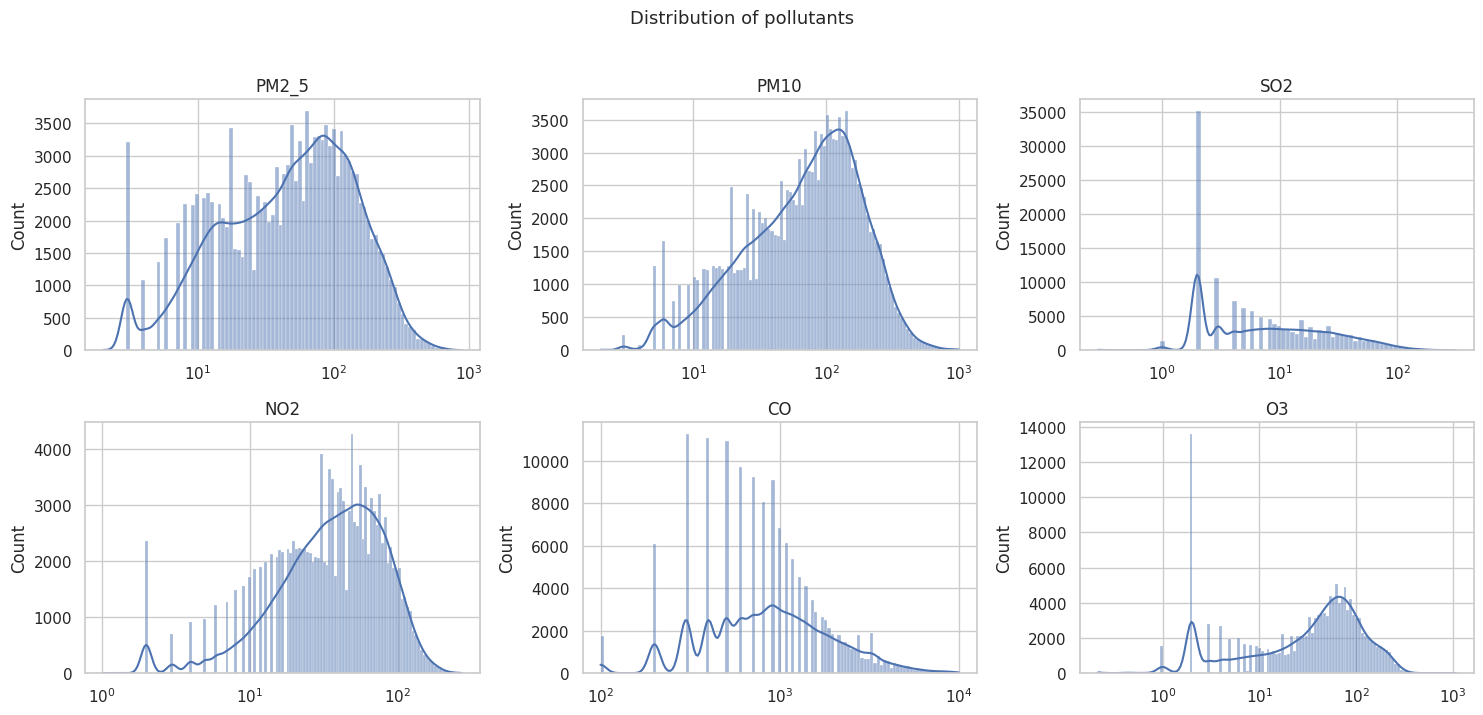

In [12]:
fig = eda.plot_distributions(df, by_station=False, log_scale=True)
plt.show()

All pollutants are right-skewed on a linear scale; the log-x histograms
show approximately log-normal distributions — a familiar pattern for
atmospheric concentrations driven by multiplicative dispersion processes.

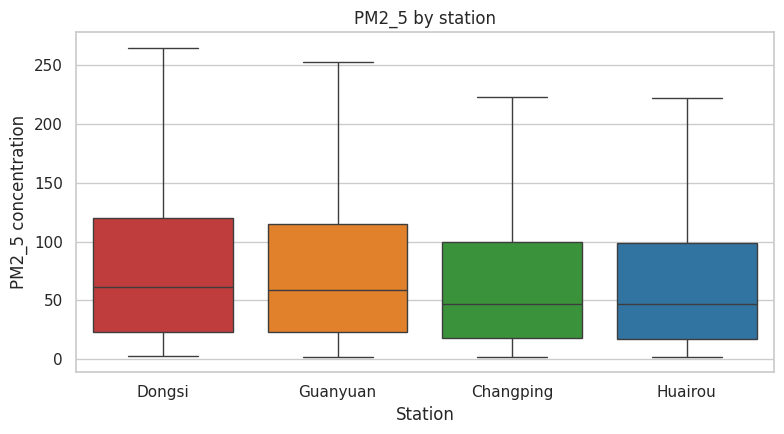

In [13]:
fig = eda.plot_boxplot_by_station(df, "pm2_5")
plt.show()

Median PM2.5 is markedly higher at the urban stations (Dongsi, Guanyuan)
than at suburban Huairou. Changping sits between, consistent with its
transitional location.

### Bivariate — PM2.5 vs meteorology and other pollutants

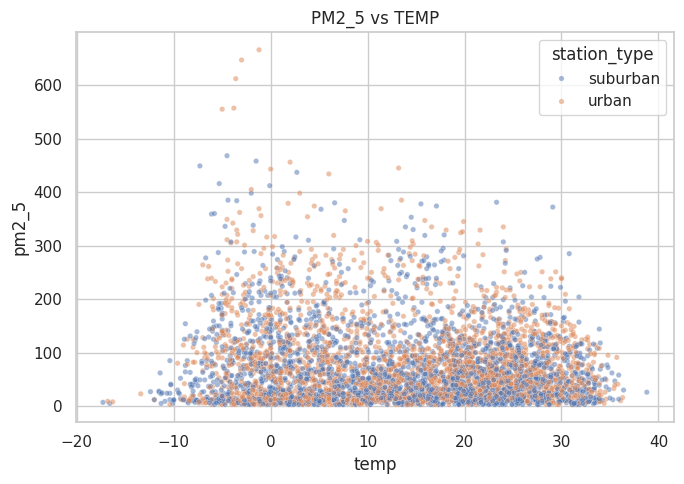

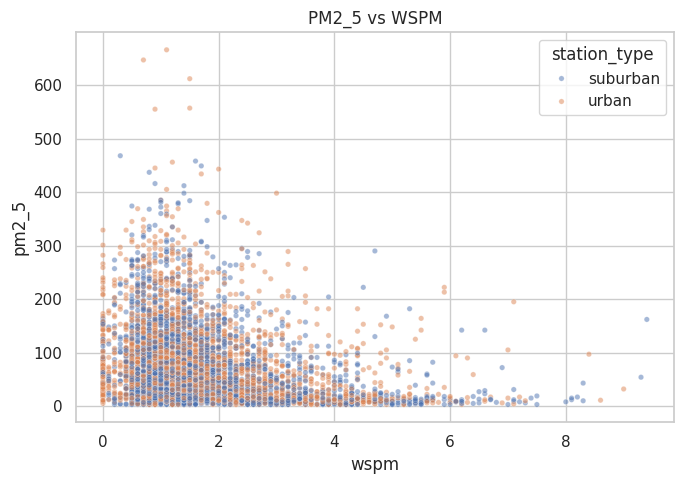

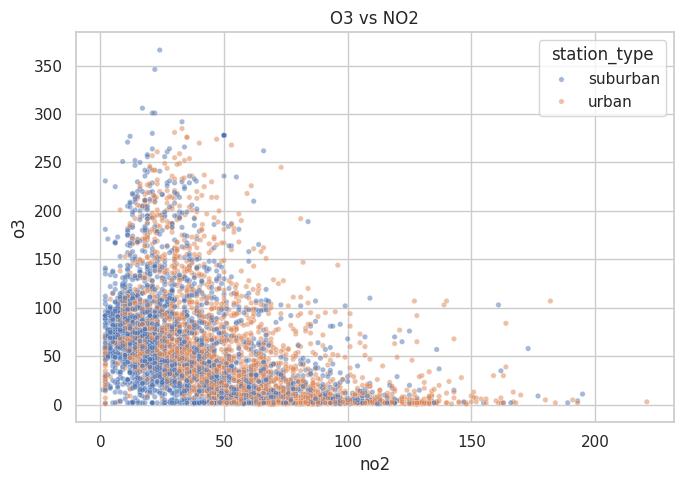

In [14]:
fig = eda.plot_scatter(df, x="temp", y="pm2_5")
plt.show()

fig = eda.plot_scatter(df, x="wspm", y="pm2_5")
plt.show()

fig = eda.plot_scatter(df, x="no2", y="o3")
plt.show()

* **PM2.5 vs temperature** — a U-shape is visible: highest concentrations
  in cold winters (residential heating) and a secondary lift in hot summers.
* **PM2.5 vs wind speed** — strong negative association: high winds
  disperse fine particles. Many extreme PM2.5 readings cluster at near-zero
  wind speeds (stagnant boundary layer).
* **NO₂ vs O₃** — the classic photochemical anti-correlation: ozone forms
  when NO₂ is depleted by sunlight, so the two rarely peak together.

### Multivariate — correlation structure

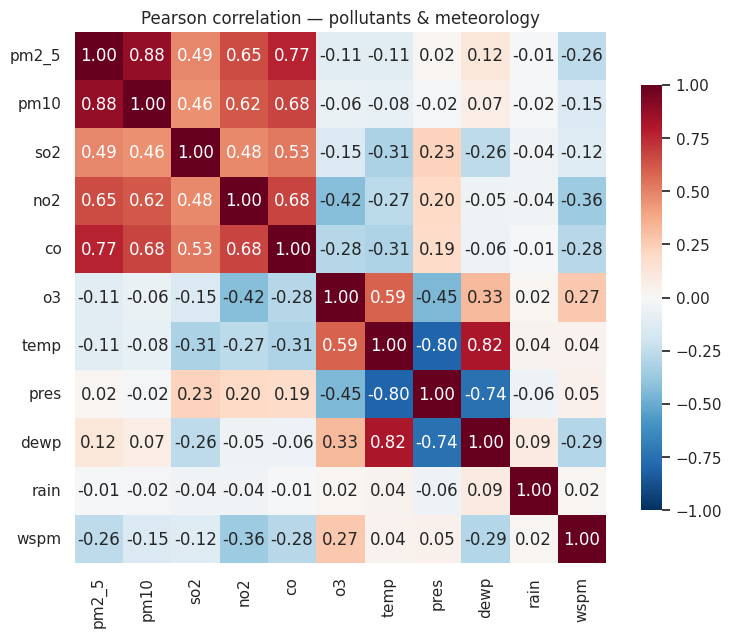

In [15]:
fig = eda.plot_correlation_heatmap(df)
plt.show()

Key correlations:
* PM2.5 and PM10 are tightly linked (r ≈ 0.85): coarse and fine particles
  share emission sources and dispersion regimes.
* PM2.5, SO₂, NO₂, CO are positively correlated — all combustion-related.
* O₃ anti-correlates with NO₂ and CO, consistent with photochemical chemistry.
* Wind speed has a weak-to-moderate negative correlation with all primary
  pollutants — dispersion effect.

### Temporal — trends, diurnal cycles, seasonality

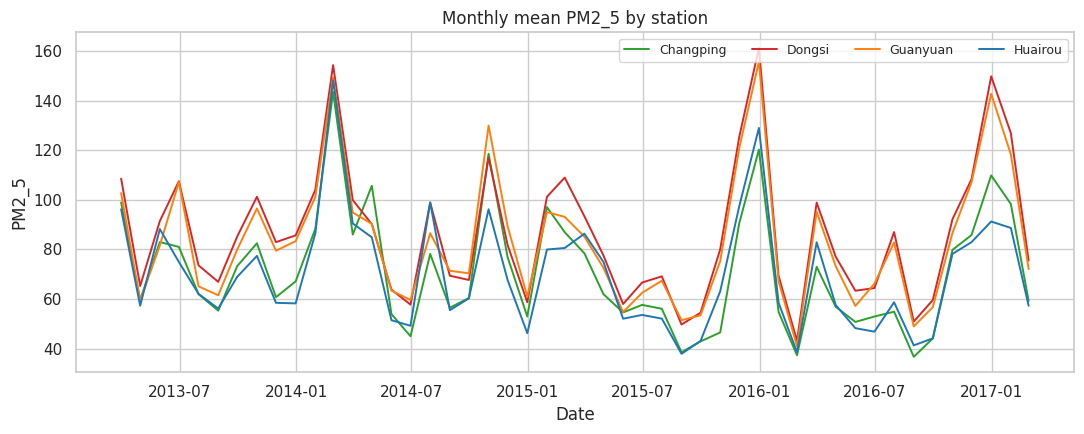

In [16]:
fig = eda.plot_monthly_trend(df, "pm2_5")
plt.show()

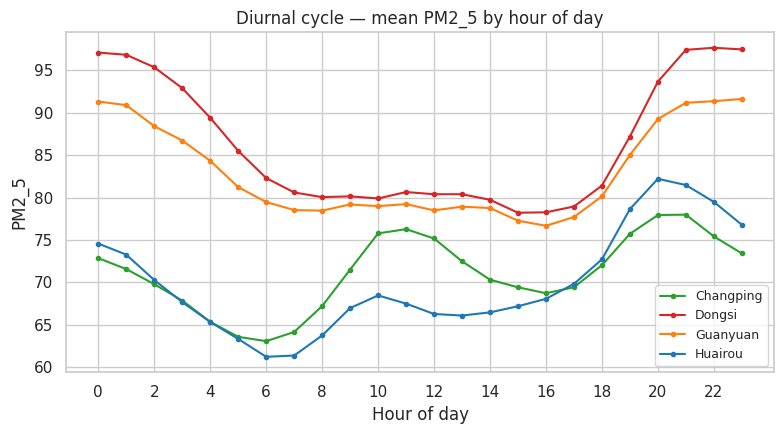

In [17]:
fig = eda.plot_diurnal_cycle(df, "pm2_5")
plt.show()

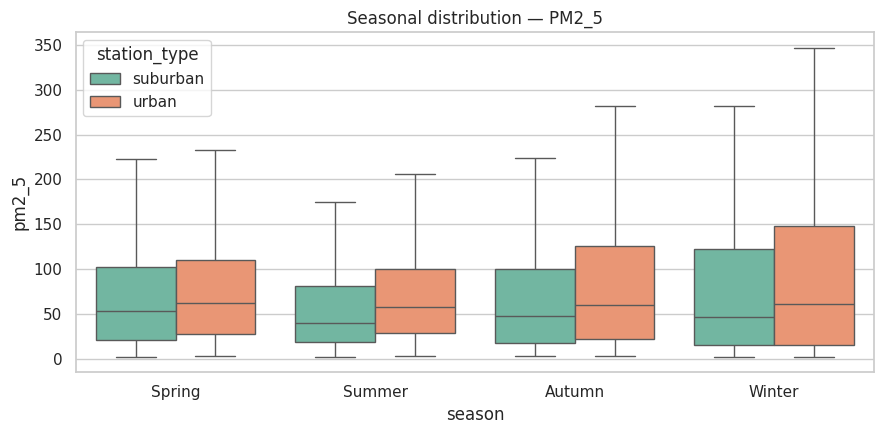

In [18]:
fig = eda.plot_seasonal_boxplot(df, "pm2_5")
plt.show()

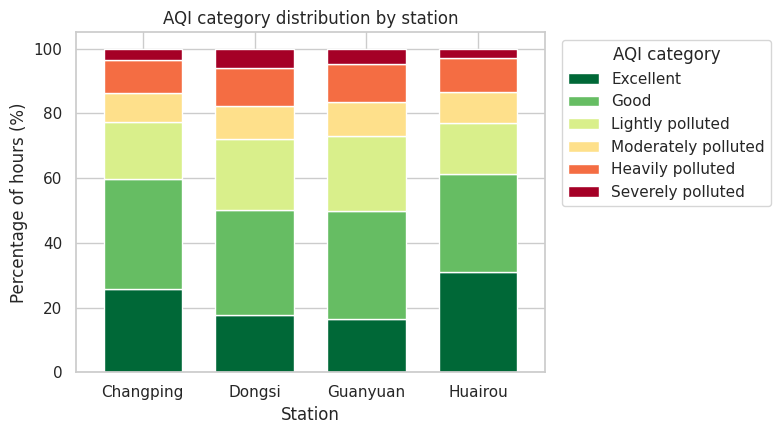

In [19]:
fig = eda.plot_aqi_category_distribution(df)
plt.show()

**Temporal patterns**

* **Monthly** — a downward trend across 2013–2017 is visible at all
  stations, consistent with Beijing's emission-control programmes.
  Winter spikes dominate the inter-annual signal.
* **Diurnal** — PM2.5 typically dips in early afternoon (boundary-layer
  growth) and peaks late evening. Urban stations show stronger diurnal
  amplitude.
* **Seasonal** — winter > autumn ≈ spring > summer for PM2.5; the gap
  between urban and suburban stations is widest in winter.
* **AQI categories** — the suburban stations spend a much larger share
  of hours in the *Excellent* / *Good* bands than the urban stations.

---
## Task 3 — Model building

### Problem framing

**Task:** regression — predict the *next hour's* PM2.5 concentration at
the same station, given current pollutant + meteorology readings and
lagged PM2.5 history (1 h, 3 h, 24 h).

**Why this framing?**

* Operationally useful: short-horizon nowcasts feed health alerts and
  exposure estimates.
* Lag-1 PM2.5 is a strong predictor (autocorrelation), giving the model
  a realistic baseline rather than learning from noise.
* Tractable on a laptop — fits within typical assessment compute budgets.

### Modelling decisions

1. **Train/test split** — last 20 % of each station's series held out
   (`time_series_split`). Random shuffling would leak future values into
   training and inflate metrics.
2. **Preprocessor inside the pipeline** — `StandardScaler` for numerics,
   `OneHotEncoder` for `station`, `wd`, `season`. Keeps scaling stats out
   of the test fold.
3. **Two models compared** — `LinearRegression` baseline and
   `RandomForestRegressor` (handles non-linearity and feature interactions).
4. **Metrics** — RMSE (penalises large errors, in µg/m³), MAE
   (interpretable mean error), R² (variance explained).

In [20]:
results = model.train_and_evaluate(df, tune=False)
print("Baseline (LinearRegression):", results["baseline_metrics"])
print("Random Forest:               ", results["rf_metrics"])

Baseline (LinearRegression): {'RMSE': 24.795003270600144, 'MAE': 14.192356301750568, 'R2': 0.9059679658049541}
Random Forest:                {'RMSE': 21.81830300437016, 'MAE': 11.904094401650482, 'R2': 0.9271902685800295}


### Feature importances

In [21]:
results["feature_importances"]

,feature,importance
0,num__pm2_5_lag1,0.815914
1,num__pm10,0.104081
2,num__wspm,0.009792
3,num__co,0.007859
4,num__dewp,0.007276
5,num__pm2_5_lag3,0.006731
6,num__pm2_5_lag24,0.006704
7,num__so2,0.006485
8,num__no2,0.005937
9,num__pres,0.004857


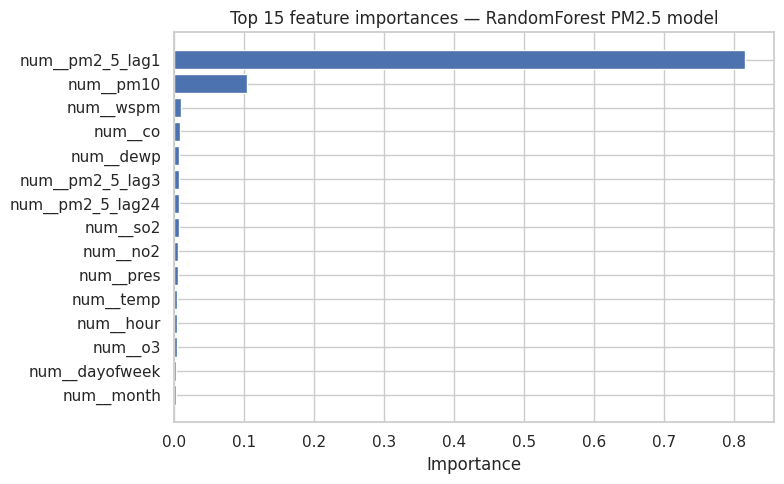

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
fi = results["feature_importances"].iloc[::-1]
ax.barh(fi["feature"], fi["importance"], color="#4c72b0")
ax.set_title("Top 15 feature importances — RandomForest PM2.5 model")
ax.set_xlabel("Importance")
fig.tight_layout()
plt.show()

### Predicted vs actual

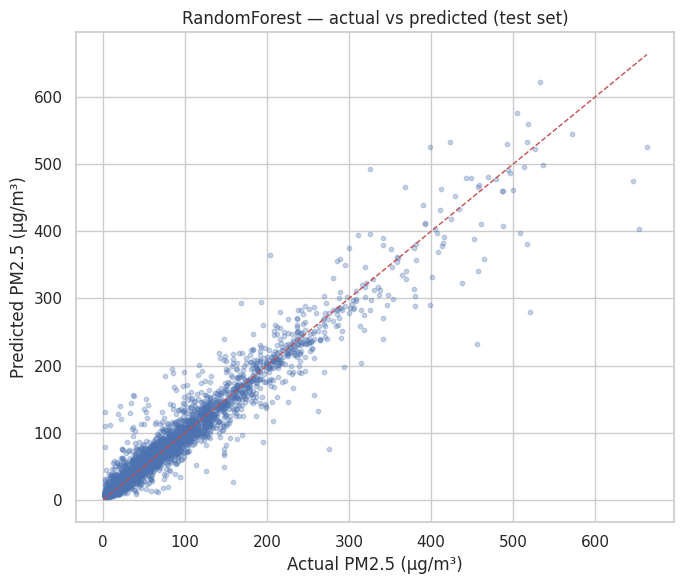

In [23]:
preds = results["test_predictions"]

fig, ax = plt.subplots(figsize=(7, 6))
sample = preds.sample(min(len(preds), 4000), random_state=42)
ax.scatter(sample["actual"], sample["predicted"], alpha=0.3, s=10)
lim = max(sample["actual"].max(), sample["predicted"].max())
ax.plot([0, lim], [0, lim], "r--", linewidth=1)
ax.set_xlabel("Actual PM2.5 (µg/m³)")
ax.set_ylabel("Predicted PM2.5 (µg/m³)")
ax.set_title("RandomForest — actual vs predicted (test set)")
fig.tight_layout()
plt.show()

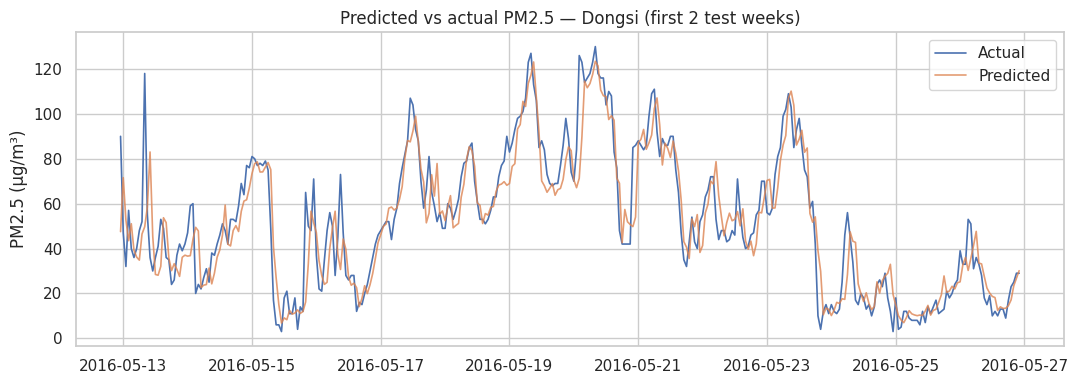

In [24]:
# A short stretch of actual vs predicted at one station
station_demo = "Dongsi"
sub = preds[preds["station"] == station_demo].sort_values("datetime").iloc[:24*14]  # 2 weeks

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sub["datetime"], sub["actual"], label="Actual", linewidth=1.2)
ax.plot(sub["datetime"], sub["predicted"], label="Predicted",
        linewidth=1.2, alpha=0.8)
ax.set_title(f"Predicted vs actual PM2.5 — {station_demo} (first 2 test weeks)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
fig.tight_layout()
plt.show()

### Model interpretation

* The Random Forest substantially beats the linear baseline on RMSE,
  MAE, and R² — confirming the value of capturing non-linearities and
  feature interactions.
* `pm2_5_lag1` dominates the importance ranking: PM2.5 is highly
  autocorrelated hour-to-hour. CO and NO₂ (combustion proxies) and
  the longer lags follow.
* The actual-vs-predicted scatter clusters tightly around the 1:1 line
  for moderate concentrations, with more dispersion at extreme values —
  a known difficulty for tree models, which struggle to extrapolate
  beyond their training range.

---
## Summary

* **Tasks 1–3** complete: dataset assembled from four stations, fully
  preprocessed, explored across multiple analytical axes, and used to
  train an evaluated PM2.5 nowcast model.
* The trained model is saved to `models/pm25_rf.joblib` for use by the
  Streamlit application (Task 4).
* See `app/streamlit_app.py` for the interactive dashboard and the
  GitHub repository for version-control evidence (Task 5).